# Kapitel 4: Architektur von Large Language Models

- Das folgende Kapitel wird die Architektur des kleinsten GPT-2 Models beschrieben und gezeigt (124.000.000 Parameter)

- Benötigte Pakete:

In [4]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.8
torch version: 2.11.0
tiktoken version: 0.12.0


- In Kapitel 3 wurden der Attention mechanismus auf Grund der verbesserten Darstellung mit sehr kleinen Embedding Dimensionen implementiert
- In diesem Kapitel werden die Embedding Dimensionen und Modellgrößen einem GPT-2 Model entsprechen
- Konfigurationsdetails:
    - vocab_size definiert die Anzahl der Tokens des cl100k_base Tokenizers.
    - context_length gibt die maximale Sequenzlänge an, die das Modell 
    gleichzeitig verarbeiten kann. GPT-2 wurde mit 1024 Tokens trainiert.
    - emb_dim legt fest dass jedes Token als Vektor mit 768 Dimensionen 
    dargestellt wird, wobei jede Dimension einen semantischen Aspekt des 
    Tokens kodiert.
    - n_heads definiert die Anzahl der Attention-Heads. Jeder Head betrachtet 
    den Text aus einem anderen Blickwinkel. Mit 768 ÷ 12 = 64 Dimensionen 
    pro Head.
    - n_layers gibt die Anzahl der hintereinandergeschalteten TransformerBlöcke an.
    - drop_rate schaltet während des Trainings zufällig 10% der Verbindungen 
    aus um Overfitting zu vermeiden.
    - qkv_bias deaktiviert den zusätzlichen Bias-Parameter in der Attention, 
    was dem Standard moderner Sprachmodelle entspricht.   

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 100277,    # Vokabular Größe
    "context_length": 1024, # Kontextlänge
    "emb_dim": 768,         # Vektor Dimension
    "n_heads": 12,          # Anzahl der Attention Heads
    "n_layers": 12,         # Anzahl der Transformer Blöcke
    "drop_rate": 0.1,       # Dropout Rate
    "qkv_bias": False       # Query, Key, Value Bias
}

## 4.1 DummyGPTModel implementieren

- Im ersten Schritt implementieren wir ein grobes Gerüst eines General Pre-Trained Transformers mit Platzhaltern um die gesamtstruktur zu verstehen

In [9]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Dummy Transformer Blöcke
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]) 
        
        # Dummy LayerNorm und Output-Head
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

# Forward: Token- und Positions-Embeddings berechnen, summieren, durch Dropout schicken, durch die Dummy 
# Transformer Blöcke laufen lassen, normalisieren und schließlich die Logits für die nächsten Token vorhersagen.
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg): # Dummy Transformer Block, das nichts tut.
        super().__init__()


    def forward(self, x):
      # Dummy Forward, der die Eingabe unverändert zurückgibt.
        return x
    
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # Dummy LayerNorm, das nichts tut.

    def forward(self, x):
        # Dummy Forward, der die Eingabe unverändert zurückgibt.
        return x

#### Dummy Klasse verwenden:

In [10]:
import tiktoken # Tokenizer für die Texte verwenden, um sie in Token-IDs umzuwandeln.

tokenizer = tiktoken.get_encoding("gpt2") # GPT-2 Tokenizer verwenden, da unser Dummy-Modell auf GPT-2 Konfiguration basiert.

batch = [] # Batch von Token-IDs erstellen, indem die Texte tokenisiert und in Tensoren umgewandelt werden.

txt1 = "Ich liebe Transformer ha ha" # Zwei Beispieltexte, die tokenisiert werden sollen.
txt2 = "Ich liebe Sprachmodelle" # Zwei Beispieltexte, die tokenisiert werden sollen.

batch.append(torch.tensor(tokenizer.encode(txt1))) # Text 1 tokenisieren, in einen Tensor umwandeln und zum Batch hinzufügen.
batch.append(torch.tensor(tokenizer.encode(txt2))) # Text 2 tokenisieren, in einen Tensor umwandeln und zum Batch hinzufügen.
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[   40,   354,  6486,  1350,  3602, 16354,   387,   387],
        [   40,   354,  6486,  1350,  5522,   620,  4666, 13485]])


In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M) # Dummy GPT Modell mit der definierten Konfiguration erstellen.

logits = model(batch) # Batch von Token-IDs durch das Dummy-Modell laufen lassen, um die Logits für die nächsten Token vorherzusagen.


# 1. Logits haben Shape [2, 7, 100277] — pro Token 100277 Scores für die nächsten möglichen Tokens.
# 2 --> 2 Texte im Batch, 7 --> Sequenzlänge (Anzahl der Tokens pro Text), 100277 --> Vokabulargröße (Anzahl der möglichen nächsten Tokens).
print("Output shape:", logits.shape) 
print("logits:", logits) # Logits ausgeben, die die Vorhersagen für die nächsten Token repräsentieren.

# 2. Größten Score-Index aus 100277 möglichen nächsten Tokens für jedes Token in der Sequenz auswählen, um die vorhergesagten nächsten Token-IDs zu erhalten.
# Position des größten Scores = Token-ID des vorhergesagten nächsten Tokens.
predicted_ids = torch.argmax(logits, dim=-1)
print("\nPredicted TokenIDs Satz 1:", predicted_ids[0].tolist())
print("Predicted TokenIDs Satz 2:", predicted_ids[1].tolist())

# 3. Token-IDs zurück in lesbaren Text umwandeln, um die vorhergesagten nächsten Tokens zu sehen.
predicted_tokens_1 = tokenizer.decode(predicted_ids[0].tolist())
predicted_tokens_2 = tokenizer.decode(predicted_ids[1].tolist())
print("\nPredicted Tokens Satz 1:", predicted_tokens_1)
print("Predicted Tokens Satz 2:", predicted_tokens_2)








Output shape: torch.Size([2, 8, 50257])
logits: tensor([[[ 0.7336, -1.1718,  0.0319,  ..., -0.5045,  0.3875, -0.0966],
         [-0.2137, -0.5371,  0.0305,  ...,  0.9313,  0.4393,  0.8954],
         [ 0.9299, -0.7605, -0.5757,  ...,  0.4171,  1.1669, -0.5149],
         ...,
         [-0.3961,  1.1770,  0.3591,  ...,  1.0325, -1.0188, -0.1571],
         [ 0.3375,  0.4295,  1.0041,  ...,  0.0663,  0.5144,  0.8624],
         [ 0.3905,  1.5745,  0.6406,  ..., -0.0125, -0.5562,  0.7602]],

        [[ 0.6071, -0.6882, -0.3438,  ..., -0.0882,  0.4655, -0.5635],
         [-0.3174,  0.1708,  0.3470,  ...,  1.3430,  1.0098,  0.4477],
         [ 0.9303, -0.4941, -0.8053,  ...,  0.5960,  0.3554, -0.7412],
         ...,
         [-0.0517, -0.7507,  0.4866,  ...,  0.8407, -0.1186,  0.8195],
         [ 1.0671,  0.1470, -0.2110,  ...,  1.0622, -0.4368,  0.3001],
         [ 0.5463,  0.1924, -0.7899,  ...,  0.4505,  0.3756, -0.8196]]],
       grad_fn=<UnsafeViewBackward0>)

Predicted TokenIDs Satz 1: [3

- Hier kommt jetzt nichts Sinnvolles raus weil:
- Die Embeddings sind zufällig, das Modell ist untrainiert und "weiß" also nicht was die Embeddings bedeuten, die Dummy-Blöcke verändern nichts, also sind die Logits koplett zufällig
- D.h. die vorhergesagten TokenIDs sind die, die zufällig den höchsten Score erhalten haben 


## 4.1 Layer Normalisation (LayerNorm)

- LayerNorm normalisiert die Layer Activations (=Ergebnisse die an die nächste Schicht/Layer weitergegeben werden) einer Schicht auf Mittelwert 0 und Varianz 1
- Verhindert explodierende/verschwindende Werte über viele Schichten → stabiles Training
- LayerNorm wird vor und nach der Self-Attention, innerhalb des Transformer Blocks und vor der finalen Output Schicht angewendet


#### Wie funktioniert LayerNorm:

In [12]:
# Codebeispiel: Beispielhafte Batch durch ein einfaches Layer laufen lassen und Ergebnisse mit LayerNorm vergleichen.

torch.manual_seed(123)

# Ein Batch von 2 Beispielen mit 5 
batch_example = torch.randn(2, 5) 

# Einfaches Layer mit Linear-Transformation und ReLU-Aktivierung erstellen.
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())


out = layer(batch_example) 
print("Layer Output:", out, "\n")

# Mittelwert und Varianz berechnen.
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var, "\n\n")

# LayerNorm durführen um Mittelwert 0 und Varianz 1 für jede Zeile zu erhalten. Formel: (x - mean) / sqrt(var)
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mittelwert:\n", mean)
print("Varianz:\n", var)



Layer Output: tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>) 

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>) 


Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mittelwert:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Varianz:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### LayerNorm in einer Klasse implementieren:

In [13]:
# LayerNorm Klasse normalisiert die Eingabe so, dass sie pro Zeile einen Mittelwert von 0 und eine Varianz von 1 hat.
class LayerNorm(nn.Module): 
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5 # Kleine Konstante, um Division durch Null zu vermeiden.


        # lernbarer Multiplikator, startet bei 1 (--> ändert erstmal nichts)
        # Das Modell kann damit lernen einzelne Dimensionen stärker oder schwächer zu gewichten
        self.scale = nn.Parameter(torch.ones(emb_dim)) 

        # lernbarer Shift, startet bei 0 (--> verschiebt erstmal nichts)
        # Das Modell kann damit lernen den Mittelwert gezielt zu verschieben
        self.shift = nn.Parameter(torch.zeros(emb_dim))



    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True) # Mittelwert pro Zeile berechnen 
        var = x.var(dim=-1, keepdim=True, unbiased=False) # Varianz pro Zeile berechnen 
        norm_x = (x - mean) / torch.sqrt(var + self.eps) # Normalisieren: (x - mean) / sqrt(var + eps)
        return self.scale * norm_x + self.shift # Skalieren und Verschieben: scale * norm_x + shift
    
    # Anmerkung: dim=-1 bedeutet, dass die Normalisierung über die letzte 
    # Dimension (die Embedding-Dimension=Reihen) erfolgt. 

#### Scale und Shift
- scale (×1) und shift (+0) sind trainierbare Parameter — zu Beginn ohne Effekt
- Werden beim Training angepasst, falls eine andere Verteilung die Performance verbessert
- eps verhindert Division durch 0, falls Varianz = 0

#### Biased Variance
- unbiased=False → Varianz wird durch n geteilt, nicht n-1 (kein Bessel's Correction)
- Bei großem n (z.B. emb_dim=768) ist der Unterschied zu n-1 vernachlässigbar
- GPT-2 wurde mit dieser Variante trainiert → wir übernehmen es für Kompatibilität mit den Pretrained Weights in Kapitel 5


#### LayerNorm Klasse verwenden:

In [14]:
# Beispiel Batch initialisieren
torch.manual_seed(123)
batch_example = torch.randn(4, 8)
print("Original Batch:\n", batch_example, "\n")

# Ausgabe von Tensoren ohne wissenschaftliche Notation, um die Werte besser lesbar zu machen.
torch.set_printoptions(sci_mode=False)

# LayerNorm auf den Batch anwenden
ln = LayerNorm(emb_dim=8) # LayerNorm mit Embedding-Dimension 8 erstellen.
normalized_batch = ln(batch_example)


print("Normalized Batch:\n", normalized_batch, "\n")
# Mittelwert und Varianz des normalisierten Batches berechnen, um zu überprüfen, dass sie 0 bzw. 1 sind.
mean = normalized_batch.mean(dim=-1, keepdim=True)
var = normalized_batch.var(dim=-1, keepdim=True, unbiased=False)
print("Mittelwert:\n", mean)
print("Varianz:\n", var)   

Original Batch:
 tensor([[ 0.3374, -0.1778, -0.3035, -0.5880,  0.3486,  0.6603, -0.2196, -0.3792],
        [ 0.7671, -1.1925,  0.6984, -1.4097,  0.1794,  1.8951,  0.4954,  0.2692],
        [-0.0770, -1.0205, -0.1690,  0.9178,  1.5810,  1.3010,  1.2753, -0.2010],
        [ 0.4965, -1.5723,  0.9666, -1.1481, -1.1589,  0.3255, -0.6315, -2.8400]]) 

Normalized Batch:
 tensor([[ 0.9296, -0.3386, -0.6482, -1.3485,  0.9572,  1.7247, -0.4417, -0.8344],
        [ 0.5521, -1.3996,  0.4836, -1.6160, -0.0333,  1.6756,  0.2815,  0.0562],
        [-0.6022, -1.6782, -0.7070,  0.5324,  1.2888,  0.9695,  0.9402, -0.7435],
        [ 1.0155, -0.7473,  1.4161, -0.3859, -0.3950,  0.8698,  0.0544, -1.8276]],
       grad_fn=<AddBackward0>) 

Mittelwert:
 tensor([[ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Varianz:
 tensor([[0.9999],
        [1.0000],
        [1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Die Varianz ist aufgrund der eps Konstante nicht ganz 0 

## 4.2 Aktivierungsfunktionen

- Ohne Aktivierungsfunktion sind gestapelte Schichten mathematisch äquivalent zu einer einzigen Matrixmultiplikation --> Tiefe/Anz. der Shichten bringt nichts
- Aktivierungsfunktionen führen Nicht-Linearität ein, damit das Netz komplexe, kontextabhängige Muster lernen kann
- Häufige Aktivierungsfunktionen in LLMs: ReLU (Rectified Linear Unit), GELU (Gaussian Error Linear Unit) und SwiGLU (Swish-Gated Linear Unit)

### Visualisierung GELU vs ReLU vs SwiGLU

Im Gegensatz zu ReLU (Rectified Linear Unit), welche negative Werte 
hart auf 0 setzt, dämpft GELU negative Werte sanft und kontinuierlich. 
Dies führt zu einem stabileren Gradientenfluss während des Trainings 
und besseren Ergebnissen bei Sprachmodellen. Da GPT-2 mit GELU trainiert 
wurde, wird diese Aktivierungsfunktion auch hier verwendet.

Der Plot vergleicht den Verlauf beider Aktivierungsfunktionen im Wertebereich 
von -3 bis 3. Während ReLU negative Werte hart auf 0 setzt und einen 
abrupten Knick bei x=0 aufweist, zeigt GELU einen weichen und 
kontinuierlichen Übergang mit einem kleinen negativen Bereich bei 
approximately x=-0.75. Dieser leicht negative Anteil ermöglicht einen 
besseren Gradientenfluss für negative Eingabewerte.

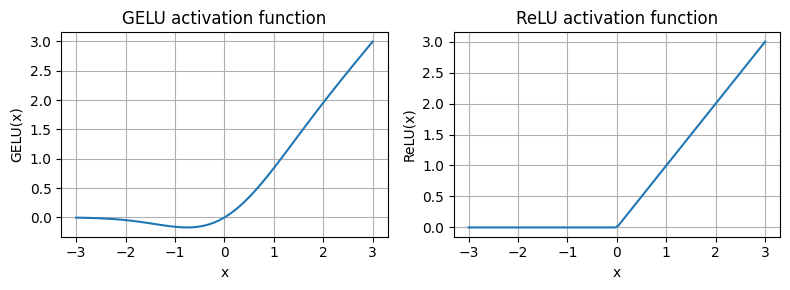

In [15]:
import matplotlib.pyplot as plt

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Feed Forward Netzwerk mit GELU Aktivierungsfunktion:

In [16]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

- Erste Linear-Schicht: Expansion 768 --> 3072 (4× emb_dim) für komplexere Repräsentation
- GELU-Aktivierung: führt Nicht-Linearität ein
- Zweite Linear-Schicht: Projektion 3072 --> 768 --> Output hat gleiche Form wie Input

## 4.3 Shortcut Connection

- Shortcut Connections wurden ursprünglich für tiefe Netze in der Computer Vision (ResNet) entwickelt, um das Vanishing Gradient Problem zu lösen.
- Sie schaffen einen alternativen, kürzeren Pfad für den Gradienten beim Backpropagation, direkt durch das Netz, ohne alle Zwischenschichten zu passieren.
- Technisch umgesetzt durch Addition: Der Input einer Schicht wird zum Output derselben Schicht addiert: x = layer(x) + x
- Dadurch können auch frühe Schichten effektiv trainiert werden, da der Gradient nicht exponentiell klein wird.

#### Beispielhaftes Neuronales Netzwerk um Effekt von Shortcut Connections zu zeigen:

In [17]:
# Beispielhafte Deep Neural Network Klasse mit optionalen Shortcut-Verbindungen,
# um die Auswirkungen auf Gradienten zu demonstrieren.
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # 5 Lineare Schichten + GELU Schicht erstellen, die die Größen in layer_sizes verwenden.
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers: # Durch die Layer iterieren
            layer_output = layer(x) # Ausgabe des aktuellen Layers berechnen

            # Check if shortcut angewendet werden soll und kann (nur wenn Shapes übereinstimmen)
            if self.use_shortcut and x.shape == layer_output.shape:
                # Output der letzten Schicht zum Output der aktuellen Schicht addieren (Shortcut-Verbindung)
                x = x + layer_output 
            else:
                x = layer_output 
        return x

#### Example Deep Neuranal Network verwenden:

In [18]:
# Funktion, um die Gradienten der Gewichte eines Modells zu berechnen und auszugeben.
def print_gradients(model, x):
    # Alle Gradienten im Modell auf Null setzen, um sicherzustellen,
    # dass sie nicht von vorherigen Berechnungen beeinflusst werden.
    model.zero_grad()

    # Vorwärtsdurchlauf durch das Modell, um die Ausgabe zu erhalten.
    output = model(x)

    # Zielwert definieren, um den Verlust zu berechnen (hier einfach eine Null-Matrix).
    target = torch.zeros_like(output)

    # Verlustfunktion loss berechnen, um die Differenz zwischen der 
    # Ausgabe und dem Zielwert zu quantifizieren.
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Rückwärtsdurchlauf durchführen, um die Gradienten der Gewichte zu berechnen.
    loss.backward()

    # Durch die  Parameter des Modells iterieren, um die Gradienten der Gewichte zu überprüfen.
    for name, param in model.named_parameters():
        if 'weight' in name:
            # Durchschnittlichen absoluten Wert der Gradienten ausgeben, um die Stärke der Gradienten zu beurteilen.
            print(f"{name} Gradientenmittelwert: {param.grad.abs().mean().item()}")



# nur die ersten 6 Werte werden für die Layergrößen verwendet,
# da die Layer nicht dynamisch erstellt werden.
layer_sizes_1 = [3, 3, 3, 3, 3, 1]
layer_sizes_2 = [3, 3, 3, 3, 3, 3] 


sample_input_0 = torch.tensor([[18., 4., 2.]])
sample_input_1 = torch.tensor([[1., 0., -1.]])


torch.manual_seed(123)
model_without_shortcut_1 = ExampleDeepNeuralNetwork(
    layer_sizes_1, use_shortcut=False
)
torch.manual_seed(123)
model_without_shortcut_2 = ExampleDeepNeuralNetwork(
    layer_sizes_2, use_shortcut=False
)

torch.manual_seed(123)
model_with_shortcut_1 = ExampleDeepNeuralNetwork(
        layer_sizes_1, use_shortcut=True
)
torch.manual_seed(123)
model_with_shortcut_2 = ExampleDeepNeuralNetwork(
        layer_sizes_2, use_shortcut=True
)

##### Beispiele ohne Shortcut Ausgeben:

In [19]:
print("Gradienten ohne Shortcut layersizes 1 [3, 3, 3, 3, 3, 1]:")
print("\nSample Input 0:", sample_input_0)
print_gradients(model_without_shortcut_1, sample_input_0)
print("\nSample Input 1:", sample_input_1)
print_gradients(model_without_shortcut_1, sample_input_1)

print("\nGradienten ohne Shortcut layersizes 2 [3, 3, 3, 3, 3, 3]:")
print("\nSample Input 0:", sample_input_0)
print_gradients(model_without_shortcut_2, sample_input_0)
print("\nSample Input 1:", sample_input_1)
print_gradients(model_without_shortcut_2, sample_input_1)


Gradienten ohne Shortcut layersizes 1 [3, 3, 3, 3, 3, 1]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 0.0004458634357433766
layers.1.0.weight Gradientenmittelwert: 0.00015799672110006213
layers.2.0.weight Gradientenmittelwert: 0.0016104783862829208
layers.3.0.weight Gradientenmittelwert: 0.0003816350654233247
layers.4.0.weight Gradientenmittelwert: 0.002110143890604377

Sample Input 1: tensor([[ 1.,  0., -1.]])
layers.0.0.weight Gradientenmittelwert: 0.00020173584925942123
layers.1.0.weight Gradientenmittelwert: 0.00012011158833047375
layers.2.0.weight Gradientenmittelwert: 0.0007152041071094573
layers.3.0.weight Gradientenmittelwert: 0.0013988735154271126
layers.4.0.weight Gradientenmittelwert: 0.005049645435065031

Gradienten ohne Shortcut layersizes 2 [3, 3, 3, 3, 3, 3]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 0.0013512189034372568
layers.1.0.weight Gradientenmittelwert: 0.0005336952162906528
layers.2.

##### Beispiele mit Shortcut ausgeben:

In [20]:
print("\nGradienten mit Shortcut layersizes 1 [3, 3, 3, 3, 3, 1]:")
print("\nSample Input 0:", sample_input_0)
print_gradients(model_with_shortcut_1, sample_input_0)
print("\nSample Input 1:", sample_input_1)
print_gradients(model_with_shortcut_1, sample_input_1)

print("\nGradienten mit Shortcut layersizes 2 [3, 3, 3, 3, 3, 3]:")
print("\nSample Input 0:", sample_input_0)
print_gradients(model_with_shortcut_2, sample_input_0)
print("\nSample Input 1:", sample_input_1)  
print_gradients(model_with_shortcut_2, sample_input_1)


Gradienten mit Shortcut layersizes 1 [3, 3, 3, 3, 3, 1]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 78.383544921875
layers.1.0.weight Gradientenmittelwert: 0.21286265552043915
layers.2.0.weight Gradientenmittelwert: 76.05632781982422
layers.3.0.weight Gradientenmittelwert: 42.11582946777344
layers.4.0.weight Gradientenmittelwert: 713.8518676757812

Sample Input 1: tensor([[ 1.,  0., -1.]])
layers.0.0.weight Gradientenmittelwert: 0.22169791162014008
layers.1.0.weight Gradientenmittelwert: 0.20694106817245483
layers.2.0.weight Gradientenmittelwert: 0.32896992564201355
layers.3.0.weight Gradientenmittelwert: 0.2665732204914093
layers.4.0.weight Gradientenmittelwert: 1.3258540630340576

Gradienten mit Shortcut layersizes 2 [3, 3, 3, 3, 3, 3]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 181.90277099609375
layers.1.0.weight Gradientenmittelwert: 10.085877418518066
layers.2.0.weight Gradientenmittelwert: 185.02346

-  Mit Shortcuts sind die Gradienten deutlich größer, weil der Gradient über zusätzliche direkte Pfade zurückfließen kann und nicht nur durch alle Layer nacheinander muss.
- Die extrem großen Gradienten entstehen vor allem durch den großen Input [[18, 4, 2]], da dadurch Output, Loss und damit auch die Gradienten stark steigen.
- Shortcuts verstärken diesen Effekt zusätzlich, weil Sie die Layer Outputs vorwärts und Gradienten rückwärts weitergeben könne. Dadurch wird verhindert, dass frühe Layer nur sehr kleine Gradienten erhalten

## 4.4 Transformer Block implementieren

- Ein Transformer Block kombiniert die gesamten Konzepte der letzten Kapitel
- Er verknüpft die in Kapitel 3 implementierte Causal Multi-Head Attention mit der LayerNorm, dem Feed Forward Netzwerk mit der GELU Aktivierungsfunktion und den Shortcut Connections
- In Kapitel 4.5 werden mehrere dieser Transformer Blöcke zu einem GPT-Model hintereinandergeschaltet

In [21]:
from  vorherigeLabs import MultiHeadAttention
import torch
import torch.nn as nn   

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # MultiHeadAttention mit den entsprechenden Parametern aus der Konfiguration erstellen.
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        
        # FeedForward Netzwerk erstellen, das die Embedding-Dimension als Eingabe und Ausgabe hat.
        self.ff = FeedForward(cfg)

        # LayerNorms für die Normalisierung vor der Attention und dem FeedForward Block erstellen.
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # Dropout für die Shortcut-Verbindungen
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
       
       # Schritt 1: Attention mit Shortcut-Verbindung
        shortcut = x # Shortcut-Verbindung für die Attention-Schicht
        x = self.norm1(x) # Normalisierung vor der Attention-Schicht
        x = self.att(x)  # MultiHeadAttention auf die normalisierte Eingabe anwenden
        x = self.drop_shortcut(x) # Dropout auf die Ausgabe der Attention-Schicht anwenden
        x = x + shortcut  # Addieren der ursprünglichen Eingabe (Shortcut) zur Ausgabe der Attention-Schicht

        # Schritt 2: FeedForward mit Shortcut-Verbindung
        shortcut = x # Shortcut-Verbindung für die FeedForward-Schicht
        x = self.norm2(x) # Normalisierung vor der FeedForward-Schicht
        x = self.ff(x) # FeedForward auf die normalisierte Ausgabe der Attention-Schicht anwenden
        x = self.drop_shortcut(x) # Dropout auf die Ausgabe der FeedForward-Schicht anwenden
        x = x + shortcut  # Addieren der Eingabe der FeedForward-Schicht (die Ausgabe der Attention-Schicht) zur Ausgabe der FeedForward-Schicht


        return x

#### Transformer Block verwenden:

In [22]:
### Beispiel Batch Initialisieren
torch.manual_seed(123)
batch_example = torch.randn(5, 10, 768) # Batch mit 5 Beispielen, Sequenzlänge 10 und Embedding-Dimension 768 erstellen.

# TransformerBlock mit der GPT-2 Konfiguration erstellen
block = TransformerBlock(GPT_CONFIG_124M)

# Batch durch den TransformerBlock laufen lassen
output = block(batch_example)

print("Input shape:", batch_example.shape) # Eingabeform überprüfen, sollte [5, 10, 768] sein.
print("Output shape:", output.shape) # Ausgabeform überprüfen, sollte [5, 10, 768] sein.

Input shape: torch.Size([5, 10, 768])
Output shape: torch.Size([5, 10, 768])


- Input- und Output-Shape sind identisch [5, 10, 768] --> der Block verfeinert die Token-Repräsentationen, macht aber noch keine Vorhersage. Diese erfolgt erst am Ende des vollständigen GPT-Modells durch den out_head (Linear 768 --> 100.277 Kontextgröße).
- Ein Block enthält ca. 7 Mio. trainierbare Parameter, verteilt auf 4 Gewichtsmatrizen (W_query, W_key, W_value, out_proj je 768x768) und 2 FeedForward-Schichten (768×3072 und 3072×768).
- Jeder einzelne Wert in diesen Matrizen ist ein trainierbares Gewicht (Parameter). Beim Erstellen des Blocks von PyTorch zufällig initialisiert, beim Training durch die Backpropagation schrittweise angepasst.



## 4.5 GPT-Modell implementieren

- Implementierung der Transformer Klasse in die Architektur aus Kapitel 4.1
- `tok_emb` wandelt Token-IDs in 768-dimensionale Vektoren um, `pos_emb` ergänzt jeden Vektor um Positionsinformationen. 
- Die Daten durchlaufen sequenziell 12 TransformerBlöcke, die die Token-Repräsentationen schrittweise verfeinern
- Abschließend normalisiert `final_norm` (LayerNorm) die Aktivierungen und `out_head` (Linear 768 → 100.277) projiziert jeden Token-Vektor auf Logits über das gesamte Vokabular
- Der Index mit dem höchsten Logit-Wert entspricht dem vorhergesagten nächsten Token


In [26]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Token- und Positions-Embeddings erstellen, die die Vokabulargröße, 
        # Kontextlänge und Embedding-Dimension aus der Konfiguration verwenden.
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout für die Embeddings erstellen, um Overfitting zu verhindern.
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # n_layers Transformer Blöcke erstellen
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # LayerNorm und Output-Head erstellen, um die Ausgabe 
        # des letzten Transformer Blocks zu normalisieren und 
        # in Logits für die nächsten Token umzuwandeln.
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        # 
        batch_size, seq_len = in_idx.shape # Batchgröße und Sequenzlänge aus der Eingabeform extrahieren
        tok_embeds = self.tok_emb(in_idx) # Token-Embeddings für die Eingabe-Token-IDs berechnen
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) # Positions-Embeddings für die Sequenzlänge berechnen
        x = tok_embeds + pos_embeds  # Token- und Positions-Embeddings summieren
        x = self.drop_emb(x) # Dropout auf die summierten Embeddings anwenden
        x = self.trf_blocks(x) # Durch die n_layers Transformer Blöcke laufen lassen
        x = self.final_norm(x) # Ausgabe des letzten Transformer Blocks normalisieren
        logits = self.out_head(x) # Logits für die nächsten Token vorhersagen
        return logits

#### GPTModel Klasse verwenden:
- Die verwendete Konfiguration GPT_CONFIG_124M wurde in Abschnitt 4.0 definiert und wird hier der Übersicht halber nochmals ausgeführt:

In [37]:
GPT_CONFIG_124M = {
    "vocab_size": 100277,    # Vokabular Größe
    "context_length": 1024, # Kontextlänge
    "emb_dim": 768,         # Vektor Dimension
    "n_heads": 12,          # Anzahl der Attention Heads
    "n_layers": 12,         # Anzahl der Transformer Blöcke
    "drop_rate": 0.1,       # Dropout Rate
    "qkv_bias": False       # Query, Key, Value Bias
}

In [38]:
torch.manual_seed(123) # Zufälligen Seed setzen, um reproduzierbare Ergebnisse zu erhalten.
tokenizer = tiktoken.get_encoding("cl100k_base") # GPT-2 Tokenizer verwenden, um Beispieltexte in Token-IDs umzuwandeln.
model = GPTModel(GPT_CONFIG_124M) # GPTModel mit der definierten Konfiguration erstellen.

# Beispiel Batch erstellen und TokenIDs generieren
batch_example = ["Ich liebe Transformer sehr sehr", "Das Modell lernt"]
batch_example = torch.tensor([tokenizer.encode(text) for text in batch_example])


# Batch durch das GPTModel laufen lassen, um die Logits für die nächsten Token vorherzusagen.
out = model(batch_example) 



print("Input batch:\n", batch_example  )
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[41469, 92442, 63479, 26574, 26574],
        [33717,  5768,   616, 76120,   406]])

Output shape: torch.Size([2, 5, 100277])
tensor([[[-0.2785,  0.2866, -0.1433,  ..., -0.1598,  0.7431, -0.6733],
         [ 0.2424,  0.5727, -1.1652,  ..., -0.5027, -0.7910,  1.1538],
         [-0.2439, -0.5094, -0.3713,  ..., -0.9278,  0.2864, -0.0444],
         [-0.6577, -0.6528, -0.5476,  ..., -0.4686, -0.0868, -0.1682],
         [ 0.7739,  0.1229,  0.6931,  ...,  0.3828, -0.2466,  0.1168]],

        [[ 0.0457, -0.5903,  0.3017,  ..., -0.7597,  0.0796, -0.0187],
         [ 0.8267,  0.3803, -0.9473,  ..., -0.6358, -0.5755,  0.3155],
         [ 0.8288, -0.7505,  0.3422,  ..., -0.9758,  1.1267,  0.5102],
         [-0.3294, -0.3897, -0.6621,  ..., -0.1529, -0.1300, -0.3406],
         [ 1.0291,  0.1576,  0.5730,  ..., -0.1179,  0.4654, -0.0789]]],
       grad_fn=<UnsafeViewBackward0>)


- Output Shape [2, 8, 100.277]: 2 Sätze × 8 Token-Positionen × 100.277 Logits (einer pro Vokabular-Token)
- Jede Position enthält eine Vorhersage welches Token als nächstes folgt.
- Da das Modell untrainiert ist, sind die Logits zufällig --> argmax liefert entsprechend bedeutungslose Token
- argmax anwenden um aus dem Output Tensor die vorhergesakten TokenIDs zu extrahieren
- TokenIDs encoden

In [ ]:
# 1. Größten Score-Index aus 100277 möglichen nächsten Tokens für jedes Token in der Sequenz auswählen, um die vorhergesagten nächsten Token-IDs zu erhalten.
# Position des größten Scores = Token-ID des vorhergesagten nächsten Tokens.
predicted_ids = torch.argmax(out, dim=-1)
print("\nPredicted TokenIDs Satz 1:", predicted_ids[0].tolist())
print("Predicted TokenIDs Satz 2:", predicted_ids[1].tolist())

# 2. Token-IDs zurück in lesbaren Text umwandeln, um die vorhergesagten nächsten Tokens zu sehen.
predicted_tokens_1 = tokenizer.decode(predicted_ids[0].tolist())
predicted_tokens_2 = tokenizer.decode(predicted_ids[1].tolist())
print("\nPredicted Tokens Satz 1:", predicted_tokens_1)
print("Predicted Tokens Satz 2:", predicted_tokens_2)


Predicted TokenIDs Satz 1: [34241, 8954, 19955, 11637, 45415, 41635, 6660, 17060]
Predicted TokenIDs Satz 2: [36397, 49494, 30964, 37408, 24285, 25787, 29290, 431]

Predicted Tokens Satz 1:  Lowe coc medieval borders Ballard Slug ThusPutin
Predicted Tokens Satz 2:  GatheringENGTH Noise lush stacks []; Whitespe


- Da das Modell untrainiert ist, liefert `argmax` bedeutungslose Token. Die Gewichte sind zufällig initialisiert und wurden noch nie angepasst. 
- In Kapitel 5 werden die Gewichte durch Training optimiert, sodass sinnvolle Vorhersagen entstehen.


### Visualisierung der Modellausgabe (Logits)

Der Plot zeigt die Logits des untrainierten GPT-Modells für den 
Eingabekontext "Recepie:". Die Logits repräsentieren die Rohausgabe 
des Modells vor der Softmax-Funktion und geben für jedes Token im 
Vokabular einen Wahrscheinlichkeitswert an.


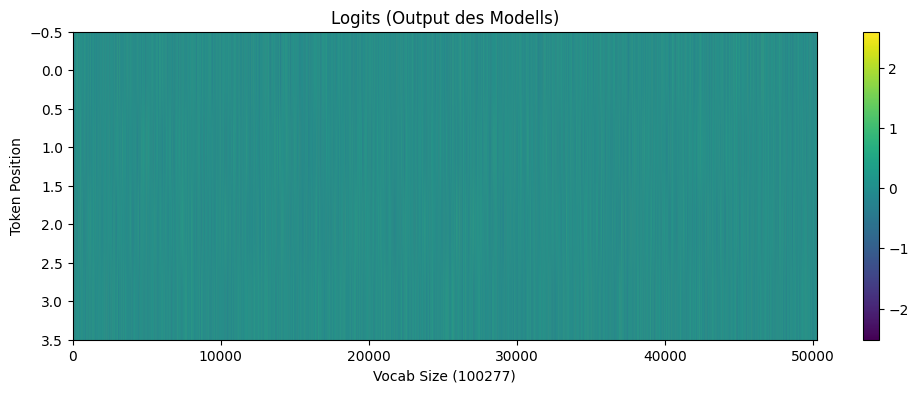

In [32]:
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")

start_context = "Recepie:"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # [1, seq_len]

model = GPTModel(GPT_CONFIG_124M)
model.eval()

with torch.no_grad():
    output = model(encoded_tensor)

if __name__ == '__main__':

    plt.figure(figsize=(12, 4))
    plt.imshow(output[0].detach().numpy(), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Logits (Output des Modells)")
    plt.xlabel("Vocab Size (100277)")
    plt.ylabel("Token Position")
    plt.show()

### Interpretation

Die Y-Achse zeigt die Token Positionen des Eingabetextes, die X-Achse 
die 100277 möglichen nächsten Tokens des Vokabulars. Da das Modell 
zu diesem Zeitpunkt noch untrainiert ist und zufällig initialisierte 
Gewichte besitzt, sind die Logits gleichmäßig verteilt ohne erkennbare 
Muster. Erst durch das Training in Lab 5 lernt das Modell sinnvolle 
Wahrscheinlichkeitsverteilungen zu erzeugen und das wahrscheinlichste 
nächste Token korrekt vorherzusagen.

### Modellgrößen im Vergleich

Da cl100k_base ein größeres Vokabular als der originale GPT-2 Tokenizer 
verwendet (100277 statt 50257 Tokens), weisen alle Modellvarianten 
eine höhere Parameteranzahl auf (GPT-Small: 239,840,256 nicht die angesprochenen 124.000.000). Die Parameteranzahl und der Speicherbedarf skalieren dabei mit der Embedding Dimension und 
der Anzahl der TransformerBlöcke.


In [43]:
configs = {
    "GPT-2 Small":  {"emb_dim": 768,  "n_heads": 12, "n_layers": 12},
    "GPT-2 Medium": {"emb_dim": 1024, "n_heads": 16, "n_layers": 24},
    "GPT-2 Large":  {"emb_dim": 1280, "n_heads": 20, "n_layers": 36},
    "GPT-2 XL":     {"emb_dim": 1600, "n_heads": 25, "n_layers": 48},
}

for name, cfg in configs.items():
    config = GPT_CONFIG_124M.copy()
    config.update(cfg)
    m = GPTModel(config)
    total = sum(p.numel() for p in m.parameters())
    print(f"{name}: {total:,} Parameter | RAM-Bedarf: {total*4/(1024*1024):.0f} MB")

GPT-2 Small: 239,840,256 Parameter | RAM-Bedarf: 915 MB
GPT-2 Medium: 508,653,568 Parameter | RAM-Bedarf: 1940 MB
GPT-2 Large: 966,272,000 Parameter | RAM-Bedarf: 3686 MB
GPT-2 XL: 1,797,856,000 Parameter | RAM-Bedarf: 6858 MB


### Weight Tying
- Auch wenn wir uns die Parameteranzahl des originalen GPT-2 Tokenizer mit unsererm GPT-Model ausgeben kommen wir immernoch nicht auf die 124.000.000 Parameter

In [44]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vokabular Größe des originalen GPT-2 Tokenizers
    "context_length": 1024, # Kontextlänge
    "emb_dim": 768,         # Vektor Dimension
    "n_heads": 12,          # Anzahl der Attention Heads
    "n_layers": 12,         # Anzahl der Transformer Blöcke
    "drop_rate": 0.1,       # Dropout Rate
    "qkv_bias": False       # Query, Key, Value Bias
}


model = GPTModel(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- Das Modell hat ca. 163M statt 124M Parameter
- Im originalen [GPT-2 paper](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C) verwendeten die Forscher Weight Tying: die Token-Embedding-Schicht tok_emb wird als Output-Schicht wiederverwendet self.out_head.weight = self.tok_emb.weight
- tok_emb projiziert die 50.257-dimensionalen Input-Token in eine 768-dimensionale Embedding-Repräsentation
- out_head projiziert die 768-dimensionalen Embeddings zurück in eine 50.257-dimensionale Repräsentation, damit diese wieder in Wörter umgewandelt werden können
- Zieht man die doppelt gezählten out_head-Parameter ab, kommt man auf die tatsächlichen ~124M einzigartigen Parameter
- 163M − (768 × 50.257) ≈ 124M einzigartige Parameter



## 4.5 Textgenerierung

- generate_text_simple implementiert Greedy Decoding: pro Schritt wird immer der Token mit dem höchsten Logit --> die Dimension mit dem höchsten Score gewählt
- Softmax ist dabei technisch unnötig --> argmax auf Logits und auf Softmax-Wahrscheinlichkeiten liefern immer denselben Index
- Greedy Decoding ist deterministisch: gleicher Input --> immer gleicher Output
- In Kapitel 5 folgt eine erweiterte generate-Funktion mit Top-k Filtering, Temperature Scaling und Sampling (torch.multinomial), die abwechslungsreichere Ausgaben ermöglicht --> hier ist Softmax zwingend nötig


In [47]:
# vocab_size wieder auf 100277 erhöhen
GPT_CONFIG_124M = {
    "vocab_size": 100277,    # Vokabular Größe des originalen GPT-2 Tokenizers
    "context_length": 1024, # Kontextlänge
    "emb_dim": 768,         # Vektor Dimension
    "n_heads": 12,          # Anzahl der Attention Heads
    "n_layers": 12,         # Anzahl der Transformer Blöcke
    "drop_rate": 0.0,       # Dropout Rate
    "qkv_bias": False       # Query, Key, Value Bias
}
# GPT-Modell initialisieren
model = GPTModel(GPT_CONFIG_124M)


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx: Tensor mit den Token-IDs des Startkontexts, Shape [batch, seq_len]
    for _ in range(max_new_tokens):
        
       # Nur die letzten context_size Token-IDs 
       # als Kontext verwenden, um die nächsten Token vorherzusagen.
        idx_cond = idx[:, -context_size:]
        
        # Modell im Inferenzmodus laufen lassen, 
        # um die Logits für die nächsten Token vorherzusagen.
        with torch.no_grad():
            logits = model(idx_cond)
        
       # Nur die Logits für das letzte Token in der Sequenz verwenden,
       # da wir nur das nächste Token vorhersagen wollen.
        logits = logits[:, -1, :]  

        # Softmax über die Logits berechnen, 
        # um die Wahrscheinlichkeiten für die nächsten Token zu erhalten.
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Token-ID mit der höchsten Wahrscheinlichkeit als nächstes Token auswählen.
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Die vorhergesagte Token-ID zum Kontext hinzufügen, 
        # um die Sequenz für die nächste Vorhersage zu erweitern.
        idx = torch.cat((idx, idx_next), dim=1)  

    return idx

#### generate_text_simple Funktion verwenden:

In [51]:
## Startkontext definieren und in Token-IDs umwandeln
start_context = "Ich liebe Transformer"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


# Die nächsten 6 Tokens generieren
out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)
# Ausgabe der generierten Token-IDs und deren Länge
print("\nOutput:", out)
print("Outputgröße:", len(out[0]))

# TokenIDs decodieren
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)



encoded: [41469, 92442, 63479]
encoded_tensor.shape: torch.Size([1, 3])

Output: tensor([[41469, 92442, 63479, 68790, 42012, 18293, 56727, 33582, 46838]])
Outputgröße: 9
Ich liebe Transformer boomingucumberTakehandlers_INLINE dés


- Das untrainierte Modell generiert bedeutungslosen Text, die Gewichte sind zufällig
- In Kapitel 5 werden die Gewichte durch Training auf echten Textdaten optimiert, sodass generate_text_simple sinnvolle Texte erzeugen kann
